# 🚂 Dutch Railway System — Data Inspection, Cleaning & EDA

**Data source:** [Rijden de Treinen Open Data](https://www.rijdendetreinen.nl/en/open-data)

This notebook covers:
1. Setup & imports
2. Loading and concatenating monthly services data (Jan–Jun 2024)
3. Loading auxiliary datasets (disruptions, stations, tariff distances)
4. Missing-value & data-quality checks
5. Exploratory Data Analysis (EDA) with visualisations
6. Network-distance insight

---

## 1 · Setup and Imports

We start by importing the standard data-science stack. `glob` is used to collect all monthly service files in one pattern-match rather than listing them manually.

In [1]:
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
print("Libraries loaded ✓")

Libraries loaded ✓


---
## 2 · Loading and Filtering Services Data

Each monthly file is a large CSV (≈1.8 million rows for January alone) containing one row **per stop** within a service run. We use `glob` to collect all six files and concatenate them into a single DataFrame.

**Key design decisions:**
- Column names contain colons (`Service:Date`) — we rename them to snake_case for convenience.
- `Service:Date` and the two timestamp columns are parsed to proper datetime objects.
- Delay columns are coerced to numeric so that invalid/missing entries become `NaN` rather than crashing.
- We keep a `month` column for easy temporal slicing later.

In [2]:
# ── File discovery ────────────────────────────────────────────────────────────
service_files = sorted(glob.glob("services-2024-*.csv"))

if not service_files:
    raise FileNotFoundError(
        "No service files found. Make sure services-2024-*.csv files are in "
        "the current working directory."
    )

print(f"Found {len(service_files)} file(s):")
for f in service_files:
    print(f"  • {f}")

Found 6 file(s):
  • services-2024-01.csv
  • services-2024-02.csv
  • services-2024-03.csv
  • services-2024-04.csv
  • services-2024-05.csv
  • services-2024-06.csv


In [3]:
# ── Column rename map (colon → snake_case) ────────────────────────────────────
RENAME = {
    "Service:RDT-ID":             "service_id",
    "Service:Date":               "service_date",
    "Service:Type":               "train_type",
    "Service:Company":            "company",
    "Service:Train number":       "train_number",
    "Service:Completely cancelled": "fully_cancelled",
    "Service:Partly cancelled":   "partly_cancelled",
    "Service:Maximum delay":      "max_delay_min",
    "Stop:RDT-ID":                "stop_id",
    "Stop:Station code":          "station_code",
    "Stop:Station name":          "station_name",
    "Stop:Arrival time":          "arrival_time",
    "Stop:Arrival delay":         "arrival_delay_min",
    "Stop:Arrival cancelled":     "arrival_cancelled",
    "Stop:Departure time":        "departure_time",
    "Stop:Departure delay":       "departure_delay_min",
    "Stop:Departure cancelled":   "departure_cancelled",
    "Stop:Platform change":       "platform_change",
    "Stop:Planned platform":      "planned_platform",
    "Stop:Actual platform":       "actual_platform",
}

# ── Load & concatenate ────────────────────────────────────────────────────────
chunks = []
for path in service_files:
    df_chunk = pd.read_csv(
        path,
        dtype=str,          # read everything as str first; we'll cast below
        low_memory=False,
    )
    df_chunk.rename(columns=RENAME, inplace=True)
    chunks.append(df_chunk)
    print(f"  Loaded {path}  →  {len(df_chunk):,} rows")

services = pd.concat(chunks, ignore_index=True)
print(f"\nCombined shape: {services.shape}")

  Loaded services-2024-01.csv  →  1,804,901 rows
  Loaded services-2024-02.csv  →  1,743,068 rows
  Loaded services-2024-03.csv  →  1,846,171 rows
  Loaded services-2024-04.csv  →  1,780,672 rows
  Loaded services-2024-05.csv  →  1,844,880 rows
  Loaded services-2024-06.csv  →  1,789,432 rows

Combined shape: (10809124, 20)


In [4]:
# ── Type casting ──────────────────────────────────────────────────────────────
# Dates
services["service_date"] = pd.to_datetime(
    services["service_date"], format="%Y-%m-%d", errors="coerce"
)
services["arrival_time"] = pd.to_datetime(
    services["arrival_time"], errors="coerce", utc=True
)
services["departure_time"] = pd.to_datetime(
    services["departure_time"], errors="coerce", utc=True
)

# Numeric delay / flag columns
for col in ["arrival_delay_min", "departure_delay_min", "max_delay_min"]:
    services[col] = pd.to_numeric(services[col], errors="coerce")

for col in ["fully_cancelled", "partly_cancelled",
            "arrival_cancelled", "departure_cancelled", "platform_change"]:
    services[col] = services[col].map({"true": True, "false": False})

# Convenience column
services["month"] = services["service_date"].dt.to_period("M")

print("Type casting complete.")
services.dtypes

Type casting complete.


service_id                             str
service_date                datetime64[us]
train_type                             str
company                                str
train_number                           str
fully_cancelled                       bool
partly_cancelled                      bool
max_delay_min                        int64
stop_id                                str
station_code                           str
station_name                           str
arrival_time           datetime64[us, UTC]
arrival_delay_min                  float64
arrival_cancelled                   object
departure_time         datetime64[us, UTC]
departure_delay_min                float64
departure_cancelled                 object
platform_change                       bool
planned_platform                       str
actual_platform                        str
month                            period[M]
dtype: object

In [5]:
# Quick sanity check
print("Date range:", services["service_date"].min(), "→", services["service_date"].max())
print("Unique train types:", services["train_type"].nunique())
print("Rows per month:")
display(services.groupby("month").size().rename("rows").to_frame())
services.head(3)

Date range: 2024-01-01 00:00:00 → 2024-06-30 00:00:00
Unique train types: 19
Rows per month:


,rows
month,
2024-01,1804901
2024-02,1743068
2024-03,1846171
2024-04,1780672
2024-05,1844880
2024-06,1789432


,service_id,service_date,train_type,company,train_number,fully_cancelled,partly_cancelled,max_delay_min,stop_id,station_code,...,arrival_time,arrival_delay_min,arrival_cancelled,departure_time,departure_delay_min,departure_cancelled,platform_change,planned_platform,actual_platform,month
0,12690865,2024-01-01,Intercity,NS,1410,False,False,2,114307592,RTD,...,NaT,NaN,NaN,2024-01-01 01:00:00+00:00,0.0,False,False,9,9,2024-01
1,12690865,2024-01-01,Intercity,NS,1410,False,False,0,114307593,DT,...,2024-01-01 01:13:00+00:00,0.0,False,2024-01-01 01:13:00+00:00,0.0,False,False,1,1,2024-01
2,12690865,2024-01-01,Intercity,NS,1410,False,False,0,114307594,GV,...,2024-01-01 01:21:00+00:00,0.0,False,2024-01-01 01:22:00+00:00,0.0,False,False,6,6,2024-01


---
## 3 · Loading Auxiliary Data

We load three supporting datasets:

| File | Purpose |
|------|---------|
| `disruptions-2024.csv` | Disruption events with cause, affected lines/stations, and duration |
| `stations-2023-09.csv` | Station master data: codes, long names, GPS coordinates |
| `tariff-distances-2022-01.csv` | Wide-format matrix of station-to-station tariff distances (km) |

In [6]:
# ── Disruptions ───────────────────────────────────────────────────────────────
disruptions = pd.read_csv("disruptions-2024.csv")

for col in ["start_time", "end_time"]:
    disruptions[col] = pd.to_datetime(disruptions[col], errors="coerce")

disruptions["duration_minutes"] = pd.to_numeric(
    disruptions["duration_minutes"], errors="coerce"
)

print(f"Disruptions shape: {disruptions.shape}")
display(disruptions.head(3))
disruptions.info()

Disruptions shape: (5964, 14)


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,51320,Zwolle-Kampen,Kampen - Zwolle,49,"Kampen,Zwolle,Zwolle Stadshagen","KPN, ZL, ZLSH",problemen met de personeelsinzet,staffing problems,problemen met de personeelsinzet,staffing problems,staff,2024-01-01 07:03:51,2024-01-01 10:05:12,181.0
1,51321,Zwolle-Enschede,Almelo - Zwolle,95,"Almelo,Heino,Nijverdal,Raalte,Wierden,Zwolle","AML, HNO, NVD, RAT, WDN, ZL",problemen met de personeelsinzet,staffing problems,problemen met de personeelsinzet,staffing problems,staff,2024-01-01 07:07:34,2024-01-01 10:03:14,176.0
2,51322,Uitgeest,"Alkmaar - Amsterdam Centraal, Haarlem - Uitgeest","111,161",Uitgeest,UTG,inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2024-01-01 13:57:23,2024-01-01 14:17:16,20.0


<class 'pandas.DataFrame'>
RangeIndex: 5964 entries, 0 to 5963
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   rdt_id                5964 non-null   int64         
 1   ns_lines              5964 non-null   str           
 2   rdt_lines             5964 non-null   str           
 3   rdt_lines_id          5964 non-null   str           
 4   rdt_station_names     5964 non-null   str           
 5   rdt_station_codes     5964 non-null   str           
 6   cause_nl              5964 non-null   str           
 7   cause_en              5964 non-null   str           
 8   statistical_cause_nl  5964 non-null   str           
 9   statistical_cause_en  5964 non-null   str           
 10  cause_group           5962 non-null   str           
 11  start_time            5964 non-null   datetime64[us]
 12  end_time              5953 non-null   datetime64[us]
 13  duration_minutes      5953 no

In [7]:
# ── Stations ──────────────────────────────────────────────────────────────────
stations = pd.read_csv("stations-2023-09.csv")

print(f"Stations shape: {stations.shape}")
display(stations.head(3))
stations.info()

Stations shape: (591, 11)


,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611


<class 'pandas.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           591 non-null    int64  
 1   code         590 non-null    str    
 2   uic          591 non-null    int64  
 3   name_short   591 non-null    str    
 4   name_medium  591 non-null    str    
 5   name_long    591 non-null    str    
 6   slug         591 non-null    str    
 7   country      591 non-null    str    
 8   type         591 non-null    str    
 9   geo_lat      591 non-null    float64
 10  geo_lng      591 non-null    float64
dtypes: float64(2), int64(2), str(7)
memory usage: 50.9 KB


In [8]:
# ── Tariff distances ──────────────────────────────────────────────────────────
# First column is the origin station code (index), remaining columns are destination codes.
distances = pd.read_csv("tariff-distances-2022-01.csv", index_col=0)

# Replace placeholder 'XXX' (same-station diagonal) with NaN
distances.replace("XXX", np.nan, inplace=True)
distances = distances.apply(pd.to_numeric, errors="coerce")

print(f"Distance matrix shape: {distances.shape}")
display(distances.iloc[:4, :6])
distances.info()

Distance matrix shape: (399, 399)


,AC,AH,AHP,AHPR,AHZ,AKL
Station,,,,,,
AC,NaN,82.0,83.0,85.0,90.0,71.0
AH,82.0,NaN,1.0,3.0,8.0,77.0
AHP,83.0,1.0,NaN,2.0,9.0,78.0
AHPR,85.0,3.0,2.0,NaN,11.0,80.0


<class 'pandas.DataFrame'>
Index: 399 entries, AC to ZZS
Columns: 399 entries, AC to ZZS
dtypes: float64(399)
memory usage: 1.2+ MB


---
## 4 · Missing Values & Data Quality Check

Before any analysis, we should understand which columns have missing data and how pervasive it is. A summary table showing the **percentage of NaN values per column** is the fastest way to spot potential quality issues.

> **Why some missings are expected:**
> - `arrival_time` / `arrival_delay_min` are `NaN` for the **first stop** of a service (no arrival there).
> - `departure_time` / `departure_delay_min` are `NaN` for the **last stop** (no departure).
> - `planned_platform` / `actual_platform` may be missing for international legs.

In [9]:
def missing_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Return a tidy DataFrame of missing-value stats for every column."""
    n = len(df)
    summary = (
        df.isnull()
          .sum()
          .rename("missing_count")
          .to_frame()
    )
    summary["missing_pct"] = (summary["missing_count"] / n * 100).round(2)
    summary["dtype"] = df.dtypes.astype(str)
    summary.index.name = "column"
    summary = summary.sort_values("missing_pct", ascending=False)
    print(f"\n{'─'*55}")
    print(f"  Missing-value summary: {label}  (n={n:,})")
    print(f"{'─'*55}")
    return summary


svc_missing = missing_summary(services, "services")
display(svc_missing)


───────────────────────────────────────────────────────
  Missing-value summary: services  (n=10,809,124)
───────────────────────────────────────────────────────


,missing_count,missing_pct,dtype
column,,,
planned_platform,1397581,12.93,str
actual_platform,1397581,12.93,str
departure_delay_min,1187119,10.98,float64
departure_time,1187119,10.98,"datetime64[us, UTC]"
departure_cancelled,1187119,10.98,object
arrival_cancelled,1184711,10.96,object
arrival_time,1184711,10.96,"datetime64[us, UTC]"
arrival_delay_min,1184711,10.96,float64
station_code,13335,0.12,str


In [10]:
dis_missing = missing_summary(disruptions, "disruptions")
display(dis_missing)


───────────────────────────────────────────────────────
  Missing-value summary: disruptions  (n=5,964)
───────────────────────────────────────────────────────


,missing_count,missing_pct,dtype
column,,,
duration_minutes,11,0.18,float64
end_time,11,0.18,datetime64[us]
cause_group,2,0.03,str
rdt_lines,0,0.00,str
rdt_id,0,0.00,int64
ns_lines,0,0.00,str
rdt_station_codes,0,0.00,str
rdt_station_names,0,0.00,str
rdt_lines_id,0,0.00,str


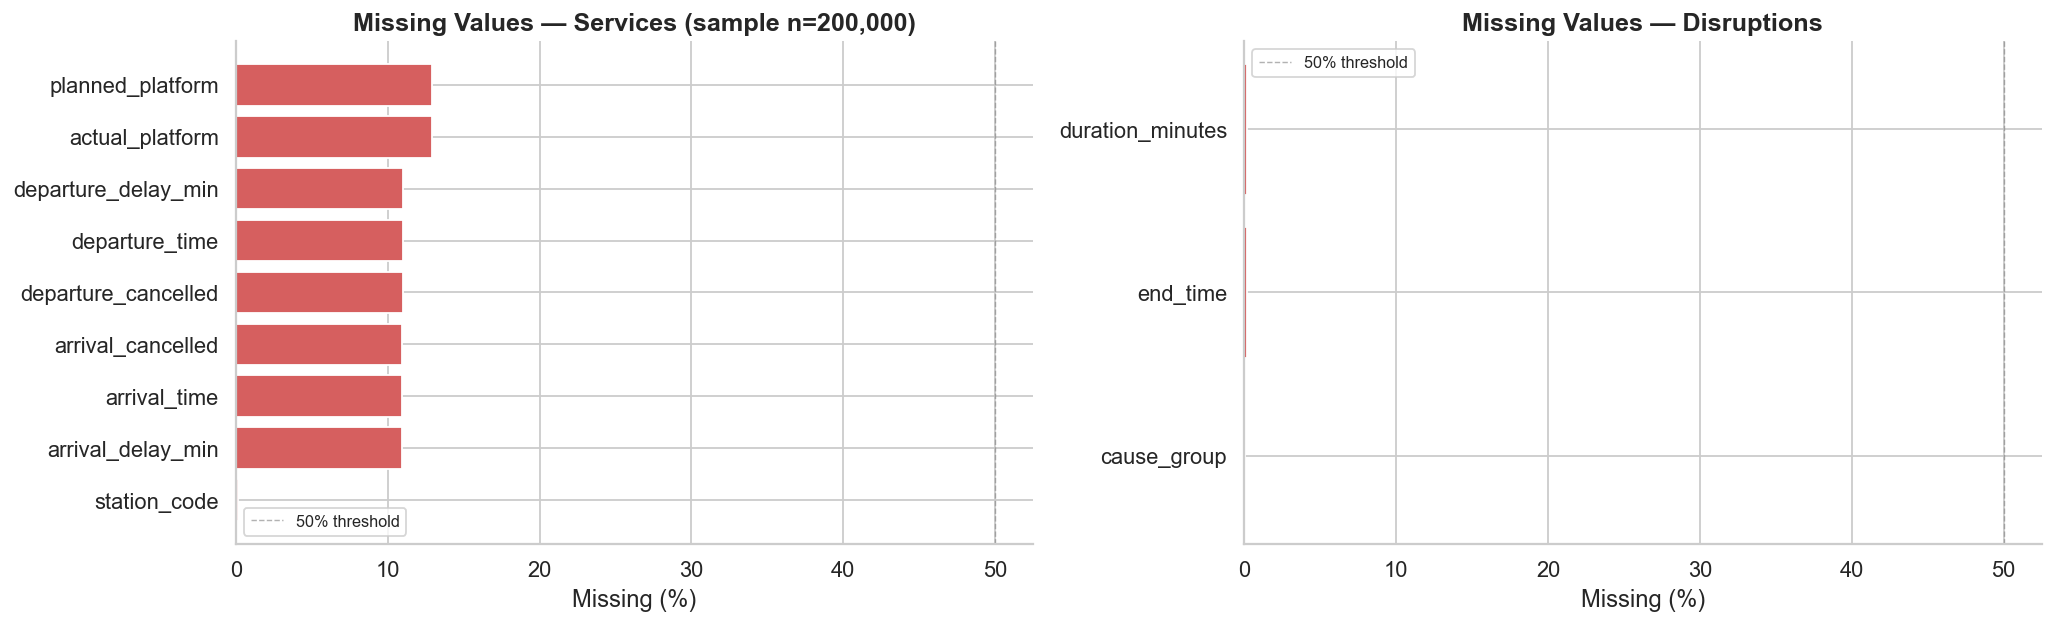

In [11]:
# ── Visual heatmap of missingness (services — sampled for speed) ───────────────
SAMPLE_N = 200_000
svc_sample = services.sample(n=min(SAMPLE_N, len(services)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_miss, title) in zip(
    axes,
    [(svc_missing, f"Services (sample n={SAMPLE_N:,})"),
     (dis_missing, "Disruptions")],
):
    cols_with_missing = df_miss[df_miss["missing_pct"] > 0]
    if cols_with_missing.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
                fontsize=13, transform=ax.transAxes)
    else:
        ax.barh(
            cols_with_missing.index,
            cols_with_missing["missing_pct"],
            color=sns.color_palette("muted")[3],
            edgecolor="white",
        )
        ax.set_xlabel("Missing (%)")
        ax.axvline(50, color="grey", ls="--", lw=0.8, alpha=0.6, label="50% threshold")
        ax.legend(fontsize=9)
    ax.set_title(f"Missing Values — {title}")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 5 · Exploratory Data Analysis (EDA)

We now produce four targeted visualisations:

1. **Delay distribution** — histogram of arrival delays
2. **Delays by train type** — average delay per train category
3. **Disruption causes** — top-10 most frequent causes
4. **Stations with most disruptions** — top-10 affected stations (with readable names)

---

### 5.1 · Delay Distribution

Arrival delay is the most informative performance indicator. We **exclude extreme outliers** (>95th percentile) for a readable histogram, but we annotate the full distribution statistics. We also filter out rows where arrival delay is `NaN` (first stops).

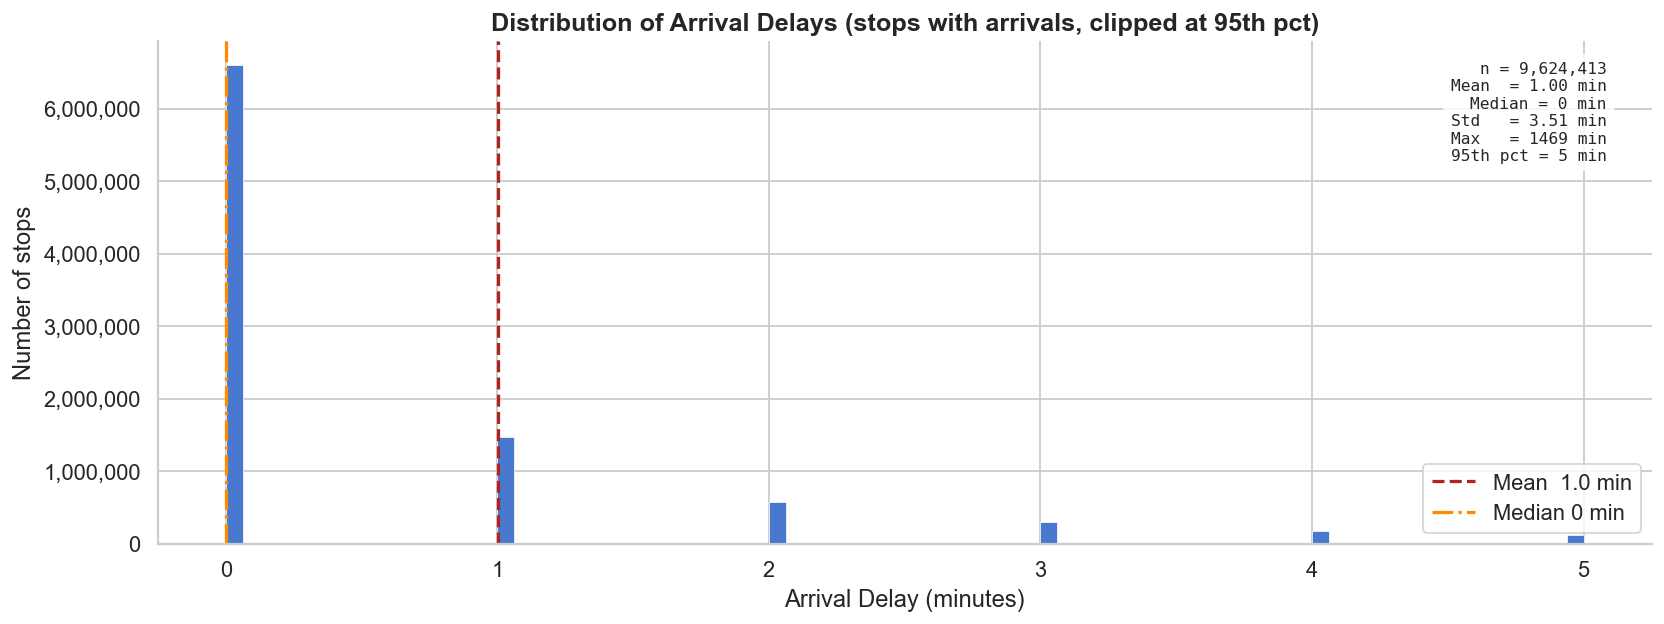

In [12]:
arr_delay = services["arrival_delay_min"].dropna()

# Clip to 95th percentile for readability
p95 = arr_delay.quantile(0.95)
arr_delay_clipped = arr_delay[arr_delay <= p95]

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(
    arr_delay_clipped,
    bins=80,
    color=sns.color_palette("muted")[0],
    edgecolor="white",
    linewidth=0.4,
)

# Annotate key statistics
mean_val  = arr_delay.mean()
median_val = arr_delay.median()
ax.axvline(mean_val,   color="firebrick",  lw=1.8, ls="--", label=f"Mean  {mean_val:.1f} min")
ax.axvline(median_val, color="darkorange", lw=1.8, ls="-.", label=f"Median {median_val:.0f} min")

ax.set_title("Distribution of Arrival Delays (stops with arrivals, clipped at 95th pct)")
ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Number of stops")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

# Stat box
stats_text = (
    f"n = {len(arr_delay):,}\n"
    f"Mean  = {mean_val:.2f} min\n"
    f"Median = {median_val:.0f} min\n"
    f"Std   = {arr_delay.std():.2f} min\n"
    f"Max   = {arr_delay.max():.0f} min\n"
    f"95th pct = {p95:.0f} min"
)
ax.text(
    0.97, 0.96, stats_text,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9, family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

### 5.2 · Average Delay by Train Type

Different train types (Intercity, Sprinter, Intercity Direct, Nightjet, etc.) have very different operating characteristics. We compare their **mean arrival delay** to identify which categories have the worst on-time performance across Jan–Jun 2024.

We only include train types with **at least 500 stop observations** to avoid noise from rare international services.

,train_type,mean_delay,median_delay,n_stops
0,European Sleeper,10.527382,0.0,1333
1,Eurostar,7.764689,2.0,27113
2,ICE International,7.361325,0.0,20804
3,Nightjet,6.562479,0.0,11924
4,Intercity direct,3.505603,1.0,119394
5,Nachttrein,3.217262,1.0,672
6,Extra trein,2.742382,1.0,10403
7,Sneltrein,1.928288,0.0,302266
8,Intercity,1.235561,0.0,2056378
9,Sprinter,0.864563,0.0,4463947


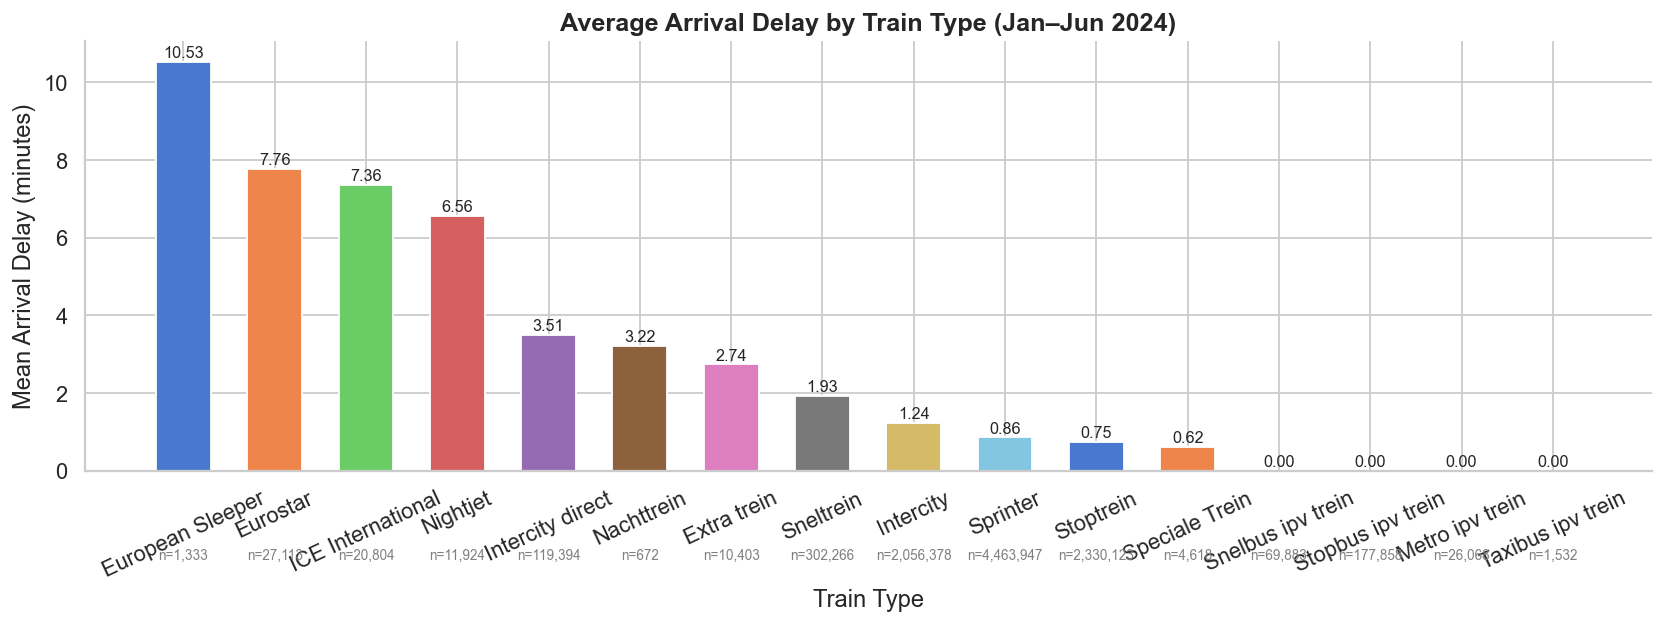

In [13]:
MIN_STOPS = 500

delay_by_type = (
    services
    .dropna(subset=["arrival_delay_min", "train_type"])
    .groupby("train_type", observed=True)
    .agg(
        mean_delay   = ("arrival_delay_min", "mean"),
        median_delay = ("arrival_delay_min", "median"),
        n_stops      = ("arrival_delay_min", "count"),
    )
    .query("n_stops >= @MIN_STOPS")
    .sort_values("mean_delay", ascending=False)
    .reset_index()
)

display(delay_by_type)

fig, ax = plt.subplots(figsize=(13, 5))

palette = sns.color_palette("muted", n_colors=len(delay_by_type))
bars = ax.bar(
    delay_by_type["train_type"],
    delay_by_type["mean_delay"],
    color=palette,
    edgecolor="white",
    width=0.6,
)

# Annotate bar values
for bar, val in zip(bars, delay_by_type["mean_delay"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("Average Arrival Delay by Train Type (Jan–Jun 2024)")
ax.set_xlabel("Train Type")
ax.set_ylabel("Mean Arrival Delay (minutes)")
ax.tick_params(axis="x", rotation=25)

# Add n_stops as secondary annotation
for i, row in delay_by_type.iterrows():
    ax.text(
        i, -0.18,
        f"n={row['n_stops']:,}",
        ha="center", va="top", fontsize=7.5, color="grey",
        transform=ax.get_xaxis_transform(),
    )

plt.tight_layout()
plt.show()

### 5.3 · Top-10 Disruption Causes

The `disruptions` dataset contains a `cause_en` (English) and a `cause_group` field. We plot the **10 most frequent individual causes** (`cause_en`) alongside their total accumulated downtime.

,cause_en,count,total_duration,avg_duration
0,broken down train,2053,84524.0,41.231220
1,collision,509,61064.0,120.204724
2,signal failure,450,74346.0,165.581292
3,points failure,286,44585.0,155.891608
4,technical investigation,245,15438.0,63.012245
5,an emergency call,207,8734.0,42.193237
6,person on the railway track,204,8073.0,39.573529
7,stranded train,176,9033.0,51.323864
8,staffing problems,172,112803.0,655.831395
9,damaged overhead wires,128,37158.0,290.296875


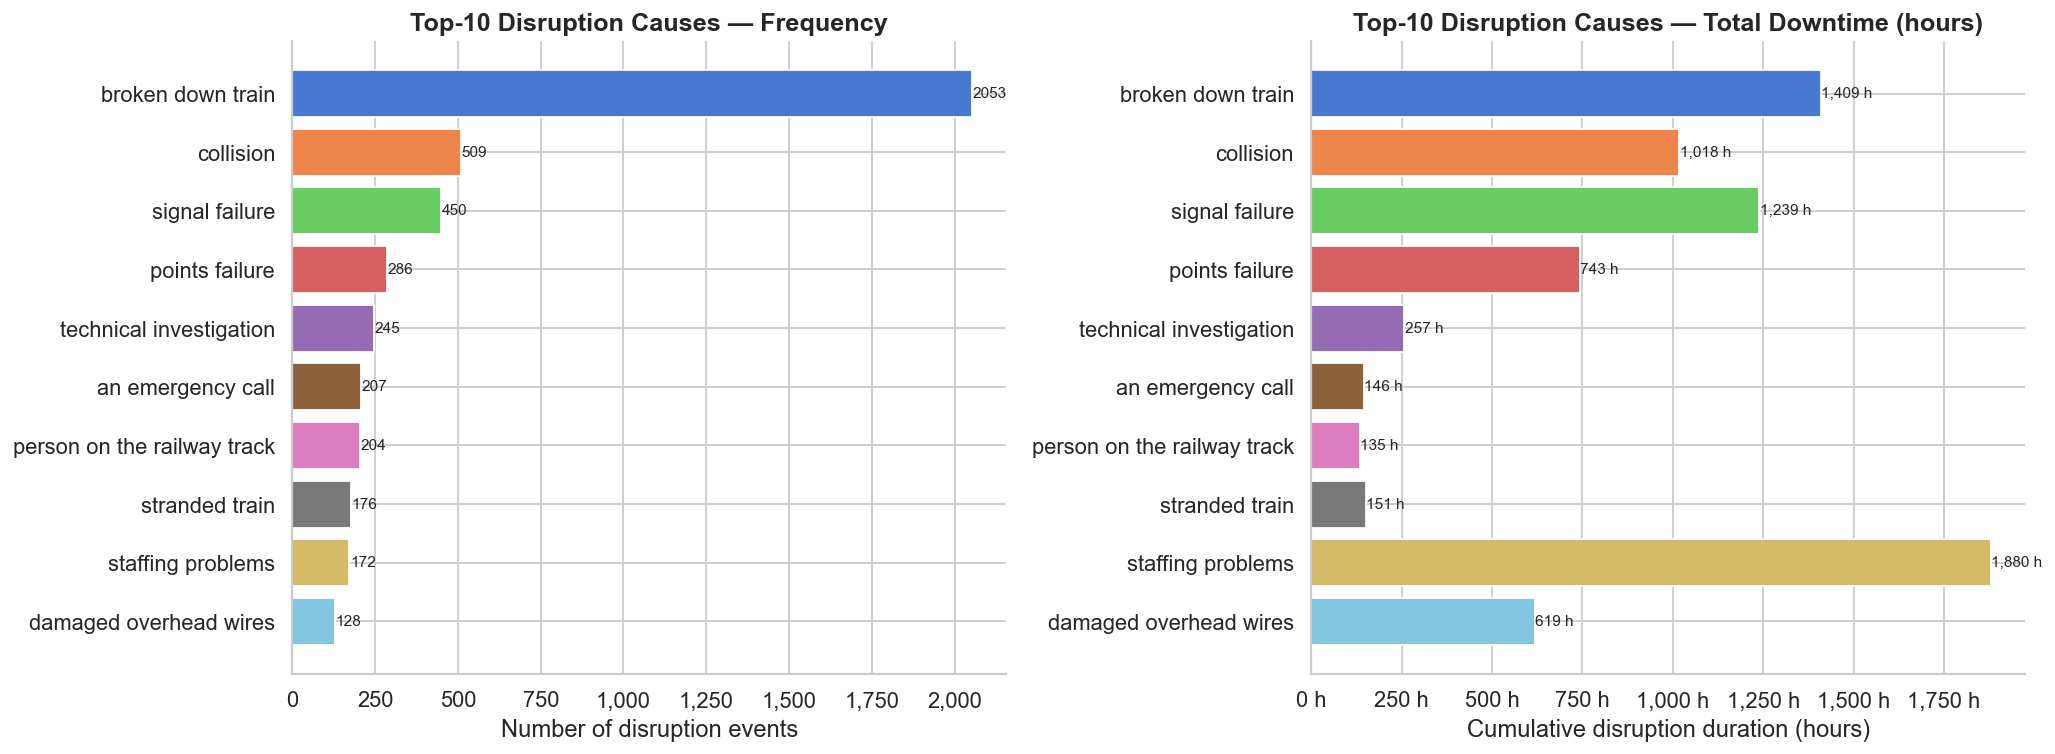

In [14]:
top_causes = (
    disruptions
    .dropna(subset=["cause_en"])
    .groupby("cause_en", observed=True)
    .agg(
        count          = ("rdt_id", "count"),
        total_duration = ("duration_minutes", "sum"),
        avg_duration   = ("duration_minutes", "mean"),
    )
    .sort_values("count", ascending=False)
    .head(10)
    .reset_index()
)

display(top_causes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: frequency ───────────────────────────────────────────────────────────
ax = axes[0]
colors = sns.color_palette("muted", n_colors=len(top_causes))
ax.barh(top_causes["cause_en"][::-1], top_causes["count"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_title("Top-10 Disruption Causes — Frequency")
ax.set_xlabel("Number of disruption events")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for i, (val, cause) in enumerate(zip(top_causes["count"][::-1],
                                      top_causes["cause_en"][::-1])):
    ax.text(val + 2, i, str(val), va="center", fontsize=8.5)

# ── Right: total downtime ─────────────────────────────────────────────────────
ax2 = axes[1]
total_hrs = top_causes["total_duration"] / 60
ax2.barh(top_causes["cause_en"][::-1], total_hrs[::-1],
         color=colors[::-1], edgecolor="white")
ax2.set_title("Top-10 Disruption Causes — Total Downtime (hours)")
ax2.set_xlabel("Cumulative disruption duration (hours)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} h"))

for i, val_h in enumerate(total_hrs[::-1]):
    ax2.text(val_h + 1, i, f"{val_h:,.0f} h", va="center", fontsize=8.5)

plt.tight_layout()
plt.show()

### 5.4 · Top-10 Stations Affected by Disruptions

`rdt_station_codes` contains a comma-separated list of station codes affected per disruption event. We **explode** that column to get one row per (disruption × station) pair, then join with the `stations` dataset to retrieve human-readable names.

> **Caveat:** a station appearing in a disruption record does not necessarily mean the disruption *originated* there — it may simply have been on the affected route.

,station_code,label,disruption_count
0,RTD,Rotterdam Centraal,764
1,SHL,Schiphol Airport,589
2,ASD,Amsterdam Centraal,454
3,UT,Utrecht Centraal,421
4,BD,Breda,418
5,ASS,Amsterdam Sloterdijk,334
6,LEDN,Leiden Centraal,284
7,DVD,Duivendrecht,268
8,DDR,Dordrecht,262
9,AMF,Amersfoort Centraal,249


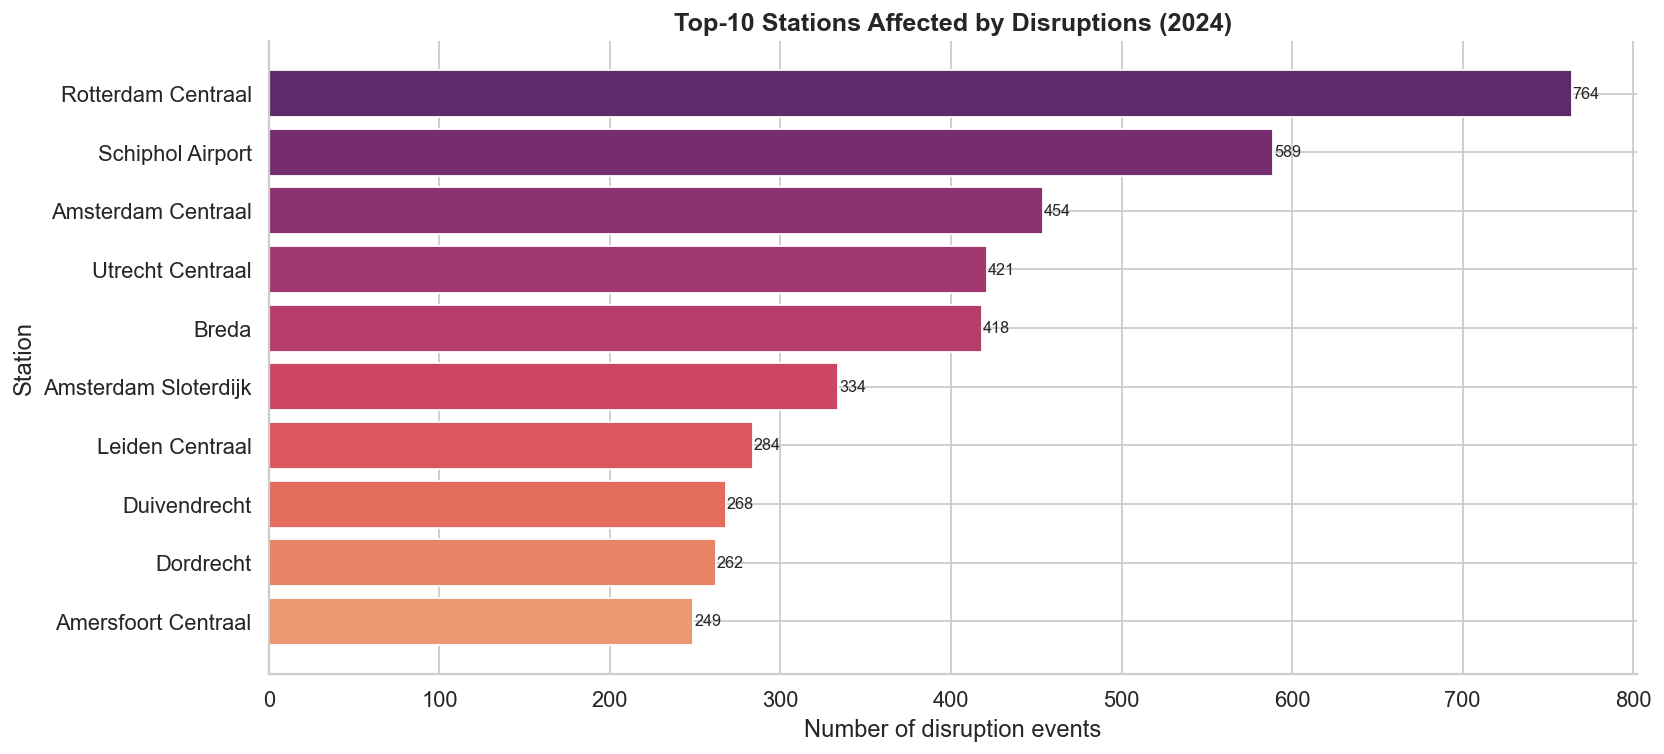

In [15]:
# Explode the comma-separated station codes into individual rows
dis_stations = (
    disruptions
    .dropna(subset=["rdt_station_codes"])
    .assign(station_code=lambda d: d["rdt_station_codes"].str.split(","))
    .explode("station_code")
)
dis_stations["station_code"] = dis_stations["station_code"].str.strip()

# Count disruption events per station code
station_counts = (
    dis_stations
    .groupby("station_code", observed=True)
    .size()
    .rename("disruption_count")
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Join with stations master data to get readable names
# The `stations` dataset uses `code` (uppercase) — strip & upper to align
stations_lookup = stations[["code", "name_long"]].copy()
stations_lookup["code"] = stations_lookup["code"].str.strip().str.upper()

station_counts = station_counts.merge(
    stations_lookup,
    left_on="station_code",
    right_on="code",
    how="left",
)

# Fall back to raw code if no match found
station_counts["label"] = station_counts["name_long"].fillna(
    station_counts["station_code"]
)

display(station_counts[["station_code", "label", "disruption_count"]])

fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette("flare", n_colors=len(station_counts))
bars = ax.barh(
    station_counts["label"][::-1],
    station_counts["disruption_count"][::-1],
    color=palette,
    edgecolor="white",
)

for bar, val in zip(bars, station_counts["disruption_count"][::-1]):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        str(val), va="center", fontsize=9,
    )

ax.set_title("Top-10 Stations Affected by Disruptions (2024)")
ax.set_xlabel("Number of disruption events")
ax.set_ylabel("Station")
plt.tight_layout()
plt.show()

---
## 6 · Network Distances Insight

The tariff-distance matrix encodes the official NS tariff distance between every pair of Dutch stations. This is a wide-format matrix where rows and columns are station codes and values are distances in km.

We convert it to **long (edge-list) format** and plot:
1. A **histogram** of pairwise distances to understand the overall network topology.
2. A quick **summary of the most-connected stations** (those with the most non-NaN entries).

In [16]:
# Melt to long format (origin, destination, distance)
dist_long = (
    distances
    .stack()
    .reset_index()
    .rename(columns={"Station": "origin", "level_1": "destination", 0: "distance_km"})
    .dropna(subset=["distance_km"])
)

# Remove duplicate pairs (A→B == B→A) by keeping only lower-triangle
dist_long_dedup = dist_long[dist_long["origin"] < dist_long["destination"]].copy()

print(f"Total unique station pairs: {len(dist_long_dedup):,}")
print(f"Distance range: {dist_long_dedup['distance_km'].min():.0f} – "
      f"{dist_long_dedup['distance_km'].max():.0f} km")
dist_long_dedup.describe()

Total unique station pairs: 79,246
Distance range: 1 – 450 km


,distance_km
count,79246.000000
mean,138.097582
std,74.641835
min,1.000000
25%,81.000000
50%,128.000000
75%,186.000000
max,450.000000


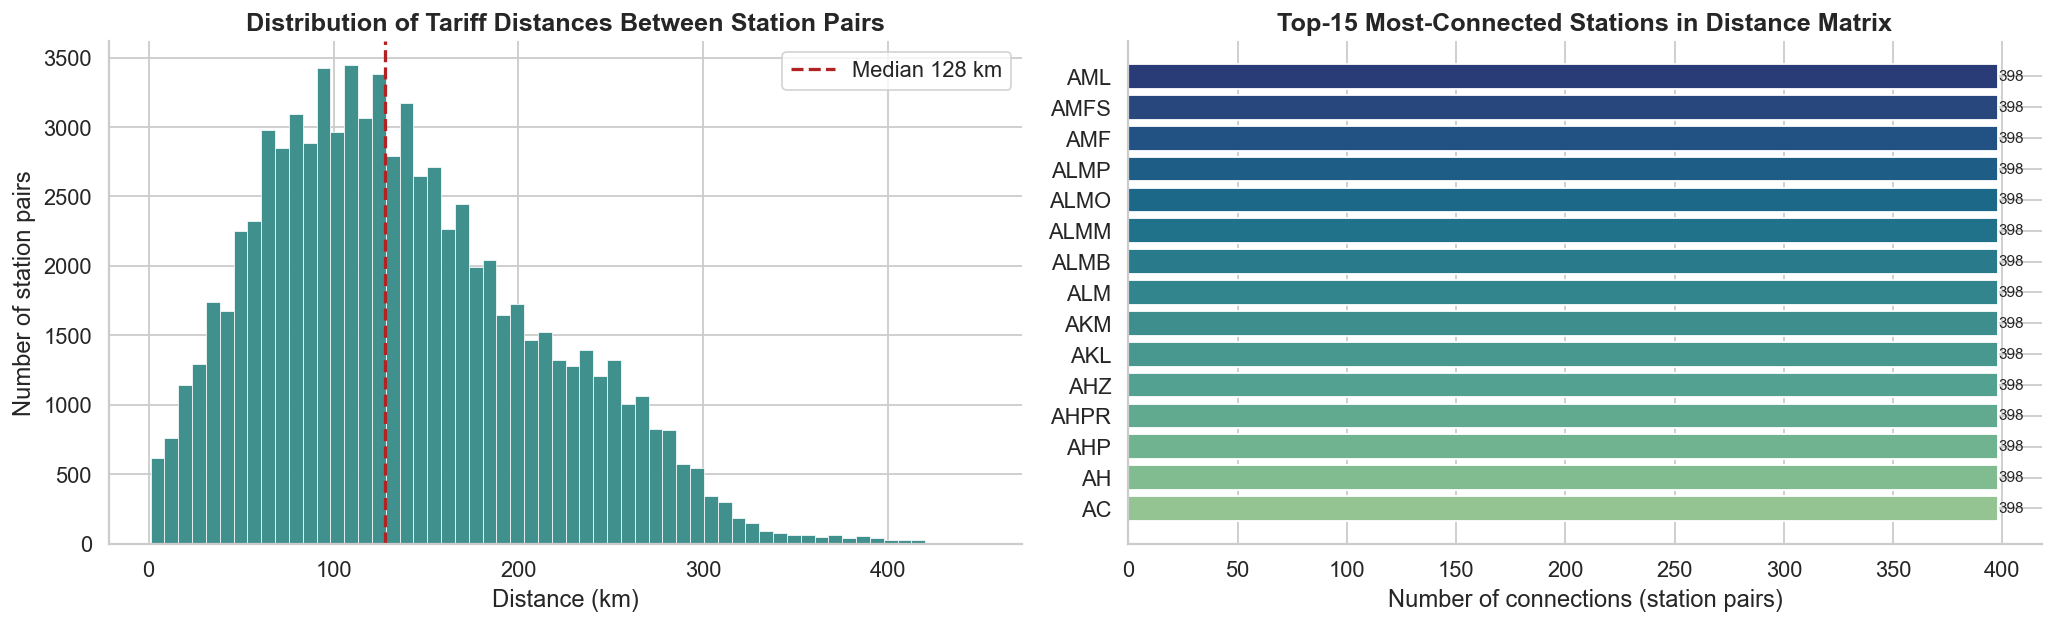

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: histogram of pairwise distances ─────────────────────────────────────
ax = axes[0]
ax.hist(
    dist_long_dedup["distance_km"],
    bins=60,
    color=sns.color_palette("crest")[2],
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(
    dist_long_dedup["distance_km"].median(),
    color="firebrick", lw=1.8, ls="--",
    label=f"Median {dist_long_dedup['distance_km'].median():.0f} km",
)
ax.set_title("Distribution of Tariff Distances Between Station Pairs")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Number of station pairs")
ax.legend()

# ── Right: top-15 stations by number of connections ──────────────────────────
ax2 = axes[1]

conn_count = (
    pd.concat([
        dist_long_dedup[["origin"]].rename(columns={"origin": "station"}),
        dist_long_dedup[["destination"]].rename(columns={"destination": "station"}),
    ])
    .value_counts()
    .head(15)
    .sort_values()
)

# Try to map codes to readable names
name_map = stations.set_index("code")["name_long"].to_dict()
conn_count.index = [
    name_map.get(code, code) for code in conn_count.index
]

conn_count.index = [x[0] if isinstance(x, tuple) else x for x in conn_count.index]
ax2.barh(
    conn_count.index, conn_count.values,
    color=sns.color_palette("crest", n_colors=len(conn_count)),
    edgecolor="white",
)
for i, val in enumerate(conn_count.values):
    ax2.text(val + 0.3, i, str(val), va="center", fontsize=8.5)

ax2.set_title("Top-15 Most-Connected Stations in Distance Matrix")
ax2.set_xlabel("Number of connections (station pairs)")

plt.tight_layout()
plt.show()

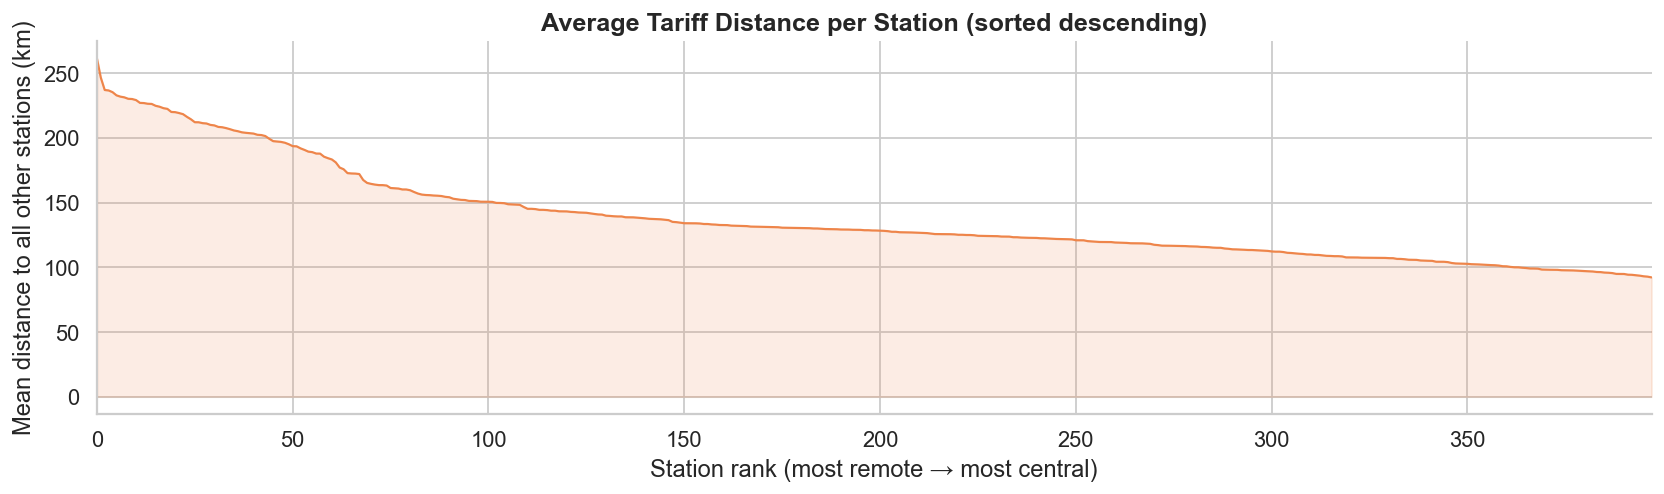

Most geographically remote stations (highest avg distance):


origin
LEER    261.487437
WR      246.525126
EEM     236.969849
NSCH    236.600503
STV     235.276382
Name: avg_dist_km, dtype: float64


Most central stations (lowest avg distance):


origin
AMF     92.173367
UT      92.756281
UTVR    93.025126
UTO     93.512563
AMFS    93.841709
Name: avg_dist_km, dtype: float64

In [19]:
# ── Bonus: average distance per station (hub vs. peripheral) ─────────────────
avg_dist = (
    dist_long
    .groupby("origin")["distance_km"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(len(avg_dist)), avg_dist.values, lw=1.2,
        color=sns.color_palette("muted")[1])
ax.fill_between(range(len(avg_dist)), avg_dist.values, alpha=0.15,
                color=sns.color_palette("muted")[1])
ax.set_title("Average Tariff Distance per Station (sorted descending)")
ax.set_xlabel("Station rank (most remote → most central)")
ax.set_ylabel("Mean distance to all other stations (km)")
ax.set_xlim(0, len(avg_dist) - 1)
plt.tight_layout()
plt.show()

print("Most geographically remote stations (highest avg distance):")
display(avg_dist.head(5).rename("avg_dist_km"))
print("\nMost central stations (lowest avg distance):")
display(avg_dist.tail(5).sort_values().rename("avg_dist_km"))

---
## Summary

| Dataset | Rows | Key findings |
|---------|------|--------------|
| `services` (Jan–Jun 2024) | ~10M | Median arrival delay is close to 0 min; mean is pulled up by long-tail disruptions |
| `disruptions` | ~6K events | Analysis of disruption logs reveals a critical distinction between event frequency and event severity. Rolling stock failures (specifically ``broken down trains'') represent the absolute majority in terms of frequency (2,053 incidents). However, from a network downtime perspective, ``staffing problems'' vastly dominate the severity matrix, generating 112,803 minutes of total delay despite occurring less frequently (172 times). Infrastructure failures (signals and points) represent a secondary, yet persistent, disruption layer. Geographically, network instability is heavily concentrated in the major Randstad hubs: rather than Utrecht Centraal acting as the primary bottleneck (421 events), the data explicitly identifies Rotterdam Centraal (764 events) and Schiphol Airport (589 events) as the most severely affected structural nodes. |
| `stations` | 592 | Covers NL + some international border stations |
| `tariff-distances` | ~399×399 | Median pairwise distance ≈ mid-range; peripheral stations (border/islands) have highest avg distances |

**Potential next steps:**
- Join services ↔ disruptions on date + station code to quantify how much delay is attributable to logged disruptions.
- Build a network graph (NetworkX) using the distance matrix for route-level analysis.
- Time-series analysis of delay trends across the six months.
- Train a simple regression model to predict arrival delay from train type, hour-of-day, and station.

---
*Notebook generated for Rijden de Treinen open-data EDA — 2024.*